In [7]:
%load_ext autoreload
%autoreload 2

import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import wandb
import torchvision
from tqdm import tqdm
import torch.nn.functional as F
from copy import deepcopy

sys.path.append(os.path.join(os.getcwd(), '../symlie'))
sys.path.append(os.path.join(os.getcwd(), '../'))

from symlie.model.networks.mlp import CombiMLP
from symlie.model.learner import CombiLearner
from symlie.misc.viz import wb_plot_pred
from symlie.run import parse_options, main, process_args
from symlie.misc.viz import wb_plot_pred

from symlie.data.transforms import TransformRefactored

from emlp.reps import V
from emlp.groups import Z, O
from emlp.datasets import O5Synthetic
from emlp.nn import gated,gate_indices,uniform_rep


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [59]:
args = parse_options(notebook=True)
args.config = 'o5synth'

args.bias = False
# args.implicit_layer_dims = [[110, 110], [11, 11]]
args.implicit_layer_dims = [5, 5]

args.grid_sizes = [[[1,2,5], [1,2,5]], [[1,1,1], [1,2,5]]]


args.lossweight_o = 1.
args.lossweight_y = 1. 
args.forward_type = 'train'

# args.do_return = True
args.logger = None

process_args(args)

# Training
model, trainer, datamodule = main(args)

Seed set to 1
/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:187: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Overwriting max_epochs = 10 to 200
[5, 5]
implicit_layer_dims <class 'list'> [5, 5]
implicit_layer_dims <class 'list'> [[100, 100, 100, 100, 100], [10, 10, 10, 10, 10]]
Init rng
Running without logging
Configuring solo optimizer
Print parameters in configure_optimizers
net.implicit_layers.0.implicit_layer.0.weight True
net.implicit_layers.0.implicit_layer.0.bias True
net.implicit_layers.0.implicit_layer.3.weight True
net.implicit_layers.0.implicit_layer.3.bias True
net.implicit_layers.0.implicit_layer.6.weight True
net.implicit_layers.0.implicit_layer.6.bias True
net.implicit_layers.0.implicit_layer.9.weight True
net.implicit_layers.0.implicit_layer.9.bias True
net.implicit_layers.1.implicit_layer.0.weight True
net.implicit_layers.1.implicit_layer.0.bias True
net.implicit_layers.1.implicit_layer.3.weight True
net.implicit_layers.1.implicit_layer.3.bias True
net.implicit_layers.1.implicit_layer.6.weight True
net.implicit_layers.1.implicit_layer.6.bias True
net.implicit_layers.1.implicit

/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/pytorch_lightning/trainer/call.py:54: Detected KeyboardInterrupt, attempting graceful shutdown...


Testing DataLoader 0: 100%|██████████| 63/63 [00:00<00:00, 455.15it/s]
No logger, skipping logging


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    21.068052291870117     │
│       test_loss_o0        │    0.2285851687192917     │
│       test_loss_o1        │   0.0024169518146663904   │
│        test_loss_y        │    20.837051391601562     │
└───────────────────────────┴───────────────────────────┘

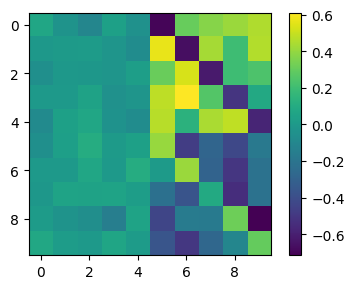

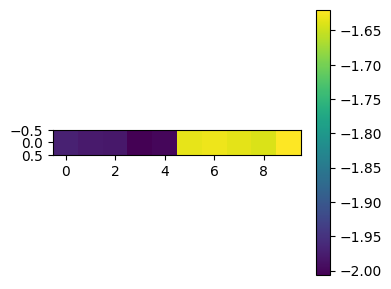

In [60]:
for layer_idx in [0, 1]:
    w, b = model.net.implicit_layers[layer_idx](
        w = model.net.vanilla_layers[layer_idx].weight.data.clone(), 
        b = model.net.vanilla_layers[layer_idx].bias.data.clone() if args.bias else None
    )

    wb_plot_pred(w, b)

In [2]:
args = parse_options(notebook=True)
args.config = 'o5synth'
# args.do_return = True
# args.logger = None

args.lossweight_o = 1.
args.lossweight_y = 1. 

process_args(args)

# Training
model, trainer, datamodule = main(args)

Seed set to 1
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


loading statedict layer0
loading statedict layer1
Init rng


wandb: Currently logged in as: eliasdubbeldam. Use `wandb login --relogin` to force relogin


/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:389: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:187: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/elias/EliasMBA/Projects/Uni/SymPDE/notebooks_symlie/../symlie/data/dataset.py:62: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3618.)
  self.y = torch.stack([self.y

Running ethereal-firefly-3143 with id 3y7xixb4
Print parameters in configure_optimizers
net.implicit_layers.0.implicit_layer.0.weight True
net.implicit_layers.0.implicit_layer.0.bias True
net.implicit_layers.0.implicit_layer.3.weight True
net.implicit_layers.0.implicit_layer.3.bias True
net.implicit_layers.0.implicit_layer.6.weight True
net.implicit_layers.0.implicit_layer.6.bias True
net.implicit_layers.1.implicit_layer.0.weight True
net.implicit_layers.1.implicit_layer.0.bias True
net.implicit_layers.1.implicit_layer.3.weight True
net.implicit_layers.1.implicit_layer.3.bias True
net.implicit_layers.1.implicit_layer.6.weight True
net.implicit_layers.1.implicit_layer.6.bias True
net.vanilla_layers.0.weight True
net.vanilla_layers.0.bias True
net.vanilla_layers.1.weight True
net.vanilla_layers.1.bias True

Testing DataLoader 0: 100%|██████████| 63/63 [00:00<00:00, 110.18it/s]
Logged regression results


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │     5.123030185699463     │
│       test_loss_o0        │    0.34459736943244934    │
│       test_loss_o1        │  0.00015768611046951264   │
│        test_loss_y        │     4.778275489807129     │
└───────────────────────────┴───────────────────────────┘

wandb: WARNING Source type is set to 'repo' but some required information is missing from the environment. A job will not be created from this run. See https://docs.wandb.ai/guides/launch/create-job


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
test_loss,▁
test_loss_o0,▁
test_loss_o1,▁
test_loss_y,▁
train_loss,█▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_o0,█▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁
train_loss_o1,█▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_y,█▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
val_loss,█▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁


In [7]:
torch.save(model.net.implicit_layers[0].implicit_layer.state_dict(), 'implicit_layer0.pt')
torch.save(model.net.implicit_layers[1].implicit_layer.state_dict(), 'implicit_layer1.pt')



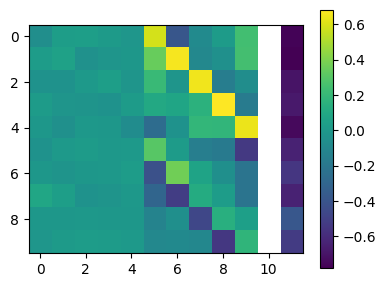

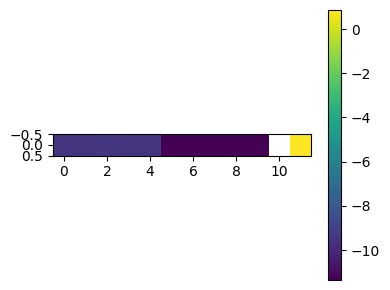

In [3]:
w, b = model.net.implicit_layers[0](
    model.net.vanilla_layers[0].weight.data.clone(), model.net.vanilla_layers[0].bias.data.clone()
)

wb_plot_pred(w, b)

w, b = model.net.implicit_layers[1](
    model.net.vanilla_layers[1].weight.data.clone(), model.net.vanilla_layers[1].bias.data.clone()
)

wb_plot_pred(w, b)



In [20]:
args = parse_options(notebook=True)
args.config = 'o5synth'
# args.do_return = True
# args.logger = None

# args.implicit_layer_dims = [[0], [0]]
# args.implicit_layer_dims = [[100, 100, 100], [10, 10, 10]]
args.implicit_layer_dims = [[110, 110, 110, 110], [11, 11, 11, 11]]
# args.implicit_layer_dims = [[110, 110], [11, 11]]
args.grid_sizes = [[[1,2,5], [1,2,5]], [[1,1,1], [1,2,5]]]
args.bias = True
args.lossweight_o = 0.
args.lossweight_y = 1. #1e-6 #0.0000001

process_args(args)

# Training
model, trainer, datamodule = main(args)

Seed set to 1


TypeError: super(type, obj): obj must be an instance or subtype of type

In [19]:
a = (1, 2), (3, 4), (5, 6)

(a1, _), (a3, _), _ = a
a1, a3

(1, 3)

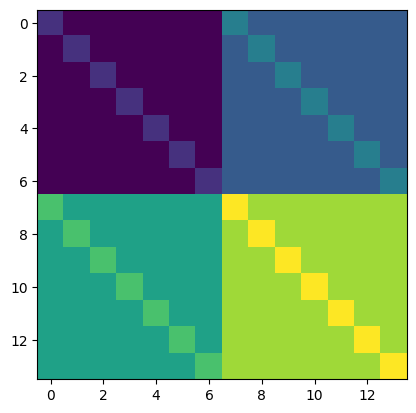

In [27]:
nn = 7

i1 = torch.zeros(nn)
i1[0] = 1
i2 = torch.cat([i1])
i3 = torch.stack([torch.roll(i2, j, 0) for j in range(nn)])
i4 = i3 + 2
i5 = torch.cat([i3, i4], dim=1)
i6 = i5 + 4
wp = torch.cat([i5, i6], dim=0)

plt.imshow(wp)

In [25]:
wp.shape

torch.Size([49, 49])

In [ ]:
def get_space_translation(size):
    w1 = torch.zeros(size)
    w1[0] = 1.
    w2 = torch.stack([torch.roll(w1, shifts = shift) for shift in range(size)])
    w3 = torch.cat([torch.roll(w2, shifts = (shift, 0), dims = (0,1)) for shift in range(size)])

    w_index = torch.zeros(size**2, size**2)
    w_index[:, :size] = w3
    return w_index


w = torch.randn(1,7)
w = ( wp @ w.flatten() ).reshape(w.shape)
plt.imshow(w)

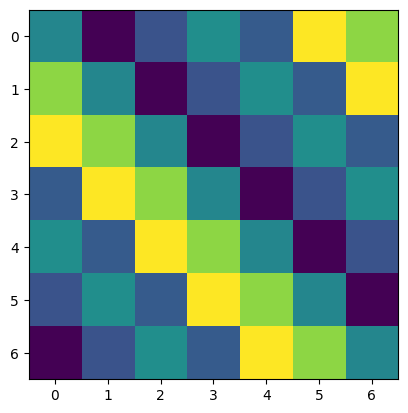

In [30]:



w = torch.randn(7,7)
w = ( wp @ w.flatten() ).reshape(w.shape)
plt.imshow(w)

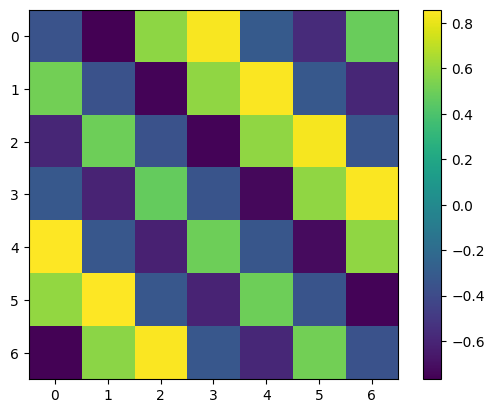

In [18]:
w, b = model.net.implicit_layers[0](
    model.net.vanilla_layers[0].weight.data.clone(), None
)

plt.imshow(w.detach())
plt.colorbar()
plt.show()

In [7]:
w, b = model.net.implicit_layers[0](
    model.net.vanilla_layers[0].weight.data.clone(),  model.net.vanilla_layers[0].bias.data.clone()
)

plt.imshow(w.detach())
plt.colorbar()
w

AttributeError: 'NoneType' object has no attribute 'data'

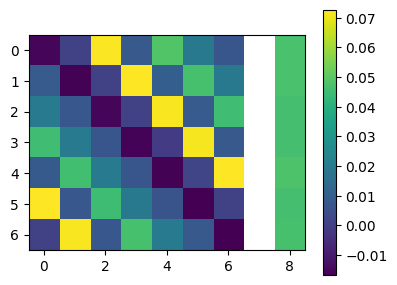

In [7]:
def wb_plot_pred(w, b, figsize = (4, 3)):
    b = b.view(-1, 1)

    wb = torch.cat([
        w,
        torch.full_like(b, torch.nan),
        b,
    ], dim = 1).detach().numpy()

    plt.figure(figsize=figsize, tight_layout=True)
    plt.imshow(wb)
    plt.colorbar()
    plt.show()

wb_plot_pred(w, b)

In [ ]:
args = parse_options(notebook=True)
args.config = 'o5synth'
# args.do_return = True
# args.logger = None

args.implicit_layer_dims = [[0], [0]]
args.bias = True
args.lossweight_o = 0.

process_args(args)

# Training
model, trainer, datamodule = main(args)

In [63]:
args = parse_options(notebook=True)
args.config = 'emlp'
# args.config = 'emlp_mlp'
args.do_return = True

args.logger = None
args.bias = True
args.lossweight_o = 0.

args.pretrained = False
args.optimizer_setting = 'solo'

process_args(args)

# Training
model, trainer, datamodule = main(args)

Seed set to 1


Initing EMLP (PyTorch)
ch=[6, 6, 6, 6, 6, 6] isinstance(ch,int)=False isinstance(ch,Rep)=False
isinstance(c, Rep): 6 False
isinstance(c, Rep): 6 False
isinstance(c, Rep): 6 False
isinstance(c, Rep): 6 False
isinstance(c, Rep): 6 False
isinstance(c, Rep): 6 False
Init rng
Running without logging


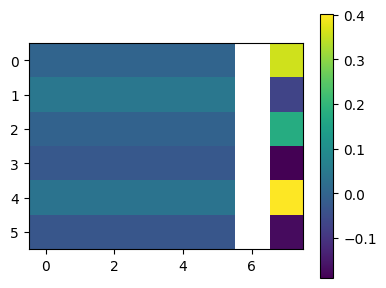

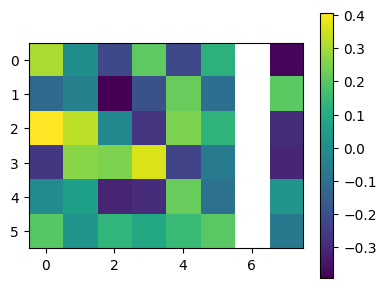

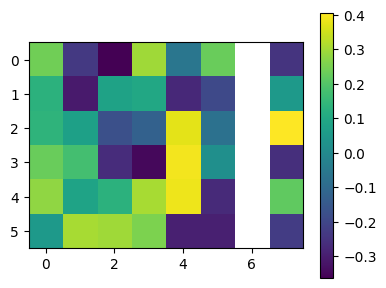

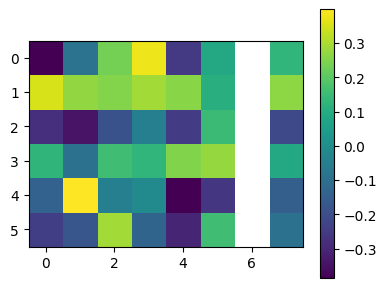

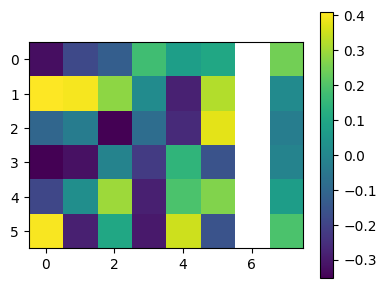

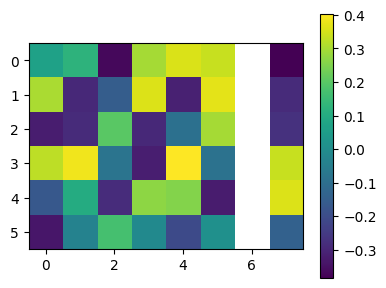

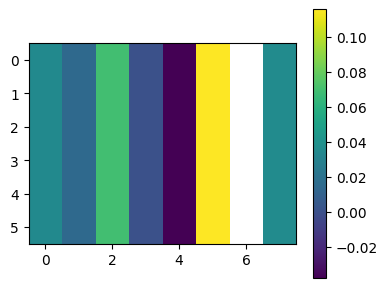

In [64]:
network = model.net.network

for layer in network:
    try:
        l = layer.linear
    except:
        l = layer
    w, b = l.proj_w(l.weight), l.proj_b(l.bias)
    wb_plot_pred(w, b)

In [3]:
# set = O5Synthetic(N = 1)
# group, repin, repout = O(5), set.rep_in, set.rep_out

# rep_in = repin(group)
# rep_in

In [49]:
net = model.net

In [50]:
print(network)

layer = network[1]
print(layer)

# l = layer
l = layer.linear
print(l)

Sequential(
  (0): EMLPBlock(
    (linear): Linear(in_features=6, out_features=10, bias=True)
    (bilinear): BiLinear()
    (nonlinearity): GatedNonlinearity()
  )
  (1): EMLPBlock(
    (linear): Linear(in_features=10, out_features=10, bias=True)
    (bilinear): BiLinear()
    (nonlinearity): GatedNonlinearity()
  )
  (2): Linear(in_features=10, out_features=6, bias=True)
)
EMLPBlock(
  (linear): Linear(in_features=10, out_features=10, bias=True)
  (bilinear): BiLinear()
  (nonlinearity): GatedNonlinearity()
)
Linear(in_features=10, out_features=10, bias=True)


In [51]:
x, y, _ = batch = next(iter(datamodule.train_dataloader()))

In [52]:
transform = TransformRefactored()
rng = torch.Generator().manual_seed(42)

In [53]:
x_prime = transform.transform(x, rng, shape = (1, 2, 5))

In [54]:
out = net(x)
out_prime = net(x_prime)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (16x10 and 6x10)

In [10]:
torch.allclose(x, x_prime), torch.allclose(out, out_prime)

(False, True)

In [22]:
for layer in network:
    print(layer)

EMLPBlock(
  (linear): Linear(in_features=10, out_features=11, bias=True)
  (bilinear): BiLinear()
  (nonlinearity): GatedNonlinearity()
)
EMLPBlock(
  (linear): Linear(in_features=10, out_features=11, bias=True)
  (bilinear): BiLinear()
  (nonlinearity): GatedNonlinearity()
)
Linear(in_features=10, out_features=1, bias=True)


In [12]:
l.reset_parameters()

l = network[1].linear
l2 = deepcopy(l)

l.weight

Parameter containing:
tensor([[-0.1207, -0.2890,  0.2758,  0.0603,  0.2828, -0.0510, -0.0795, -0.2973,
         -0.1200,  0.2074],
        [-0.3097, -0.1106,  0.1927,  0.1823,  0.1168, -0.0626, -0.0239, -0.0601,
         -0.1166,  0.1320],
        [-0.1077, -0.1777,  0.0717, -0.2286, -0.0675,  0.1616,  0.1182,  0.2692,
         -0.2157,  0.0027],
        [-0.0934, -0.1769, -0.1779,  0.0797,  0.0331, -0.1614, -0.2229, -0.2620,
          0.3099, -0.0539],
        [-0.0731, -0.1163, -0.1582, -0.2892, -0.1856,  0.1933,  0.0693, -0.1116,
         -0.1195,  0.2020],
        [ 0.2280,  0.3047,  0.0922,  0.1528, -0.0254, -0.1849, -0.3098,  0.1926,
         -0.0460,  0.1299],
        [ 0.0156, -0.2951, -0.1551,  0.0890, -0.0640, -0.3054,  0.1109,  0.0121,
         -0.1016,  0.1277],
        [ 0.0668, -0.1166,  0.2841,  0.1586,  0.0397, -0.0607, -0.2679,  0.2442,
         -0.0816, -0.2044],
        [ 0.2028,  0.1123,  0.0783, -0.0627, -0.0987,  0.0537,  0.2447,  0.0453,
         -0.1495,  0.3141

In [13]:
l2.weight.data[0,0] = 0.

In [55]:
w, b = l.proj_w(l2.weight), l.proj_b(l2.bias)
wb_plot_pred(w, b)
w

ValueError: dimension mismatch

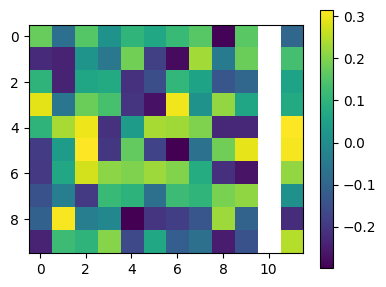

tensor([[ 0.1720, -0.0742,  0.1545,  0.0180,  0.1038,  0.0695,  0.1150,  0.1568,
         -0.2929,  0.1592],
        [-0.2223, -0.2386,  0.0192, -0.0539,  0.1857, -0.1831, -0.2811,  0.2301,
         -0.0469,  0.1779],
        [ 0.1017, -0.2371,  0.0635,  0.0760, -0.2117, -0.1500,  0.1078,  0.0566,
         -0.1345, -0.0957],
        [ 0.2896, -0.0585,  0.1783,  0.1369, -0.2044, -0.2689,  0.3035,  0.0165,
          0.2168,  0.0655],
        [ 0.1017,  0.2362,  0.2999, -0.2098,  0.0395,  0.2360,  0.2291,  0.1965,
         -0.2289, -0.2277],
        [-0.1912,  0.0397,  0.3152, -0.1998,  0.1685, -0.1750, -0.2973, -0.0672,
          0.1822,  0.2936],
        [-0.1964,  0.0686,  0.2729,  0.2095,  0.1971,  0.2247,  0.2000,  0.0817,
         -0.2162, -0.2656],
        [-0.1449, -0.0368, -0.1938,  0.1157,  0.0979, -0.0716,  0.1215,  0.1022,
          0.1931,  0.2130],
        [-0.1071,  0.3090, -0.0366, -0.0109, -0.2985, -0.2035, -0.1847, -0.1353,
          0.2248, -0.1033],
        [-0.2363,  

In [56]:
w, b = l.proj_w(l.weight), l.proj_b(l.bias)
wb_plot_pred(w, b)
w

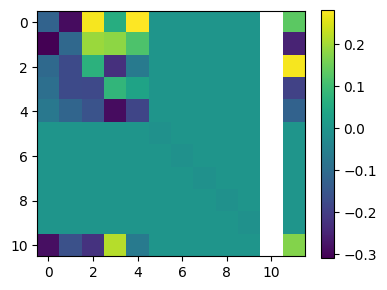

tensor([[-0.1207, -0.2890,  0.2758,  0.0603,  0.2828,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000],
        [-0.3097, -0.1106,  0.1927,  0.1823,  0.1168,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000],
        [-0.1077, -0.1777,  0.0717, -0.2286, -0.0675,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000],
        [-0.0934, -0.1769, -0.1779,  0.0797,  0.0331,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000],
        [-0.0731, -0.1163, -0.1582, -0.2892, -0.1856,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000, -0.0091,  0.0000,  0.0000,
          0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000, -0.0091,  0.0000,
          0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000, -0.0091,
          0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         -0.0091,  0.0000],
        [ 0.0000,  

In [30]:
l = net2.network[1].linear
w, b = l.proj_w(l.weight), l.proj_b(l.bias)
wb_plot_pred(w, b)
w

In [35]:
not False == True

True

In [36]:
n_f = 10

r = []
for i in range(n_f):
    for j in range(n_f):
        net2 = deepcopy(net)
        net2.network[1].linear.weight.data[i, j] = 100

        out2 = net2(x)

        if not torch.allclose(out, out2):
            r.append((i,j))
r = np.array(r)



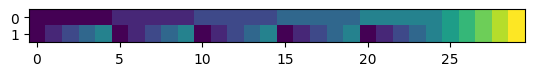

In [46]:
plt.imshow(r.T)

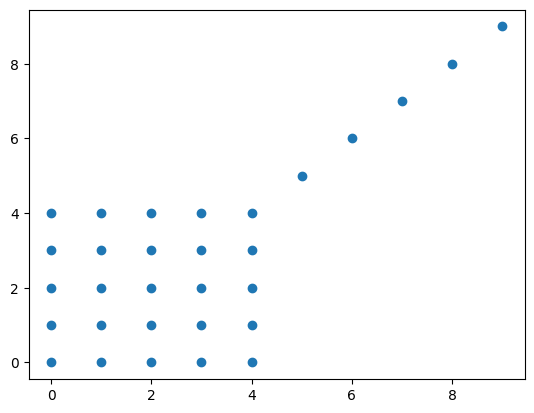

In [44]:
plt.scatter(*r.T)

In [34]:
net2.network[1].linear.weight.data.shape

torch.Size([11, 10])

In [29]:
net2 = deepcopy(net)
net2.network[1].linear.weight.data[2, 8] = 100


out = net(x)

True

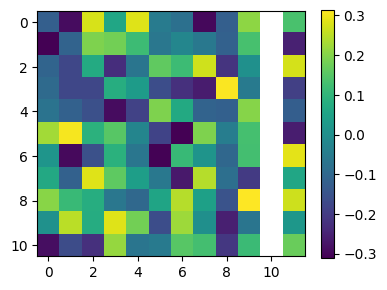

In [155]:
wu, bu = l.weight, l.bias
wb_plot_pred(wu, bu)

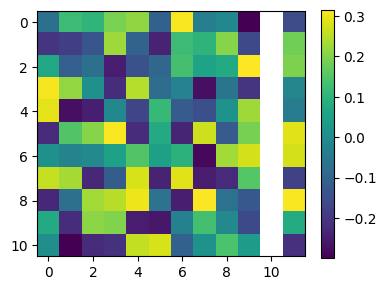

In [152]:
wu, bu = l.weight, l.bias
wb_plot_pred(wu, bu)

In [ ]:
l = network[1].linear

w, b = l.proj_w(l.weight), l.proj_b(l.bias)
wb_plot_pred(w, b)

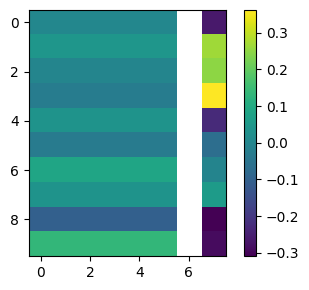

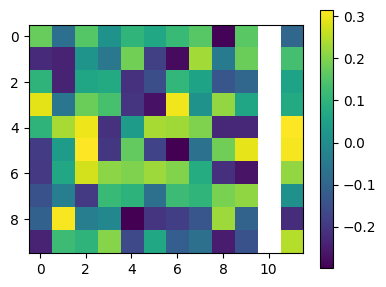

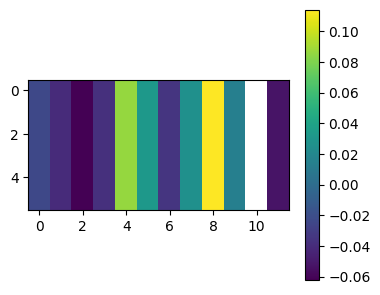

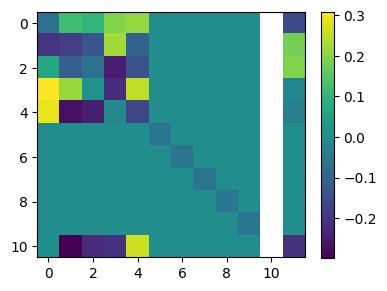

In [78]:
w

tensor([[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000],
        [-0.0420,  0.0000,  0.0000,  0.0000,  0.0000,  0.0523, -0.0000, -0.0000,
         -0.0000, -0.0000],
        [ 0.0000, -0.0420,  0.0000,  0.0000,  0.0000, -0.0000,  0.0523, -0.0000,
         -0.0000, -0.0000],
        [ 0.0000,  0.0000, -0.0420,  0.0000,  0.0000, -0.0000, -0.0000,  0.0523,
         -0.0000, -0.0000],
        [ 0.0000,  0.0000,  0.0000, -0.0420,  0.0000, -0.0000, -0.0000, -0.0000,
          0.0523, -0.0000],
        [ 0.0000,  

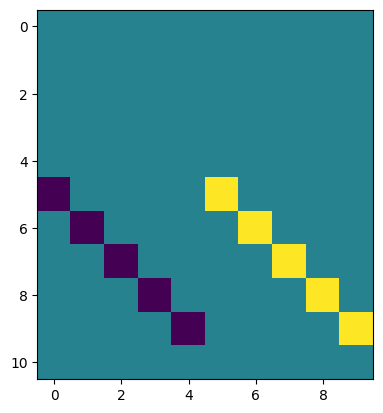

In [75]:
plt.imshow(w.detach().numpy())

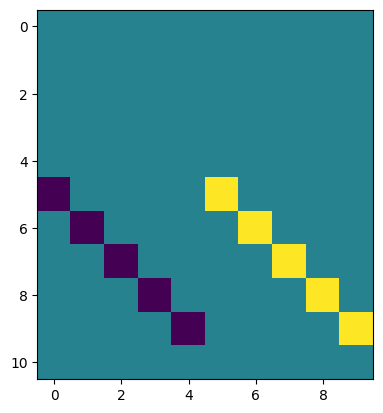

In [64]:
plt.imshow(w.detach().numpy())

In [47]:
torch.allclose(out, out_prime)

True

tensor([[-0.1876],
        [-0.1876],
        [-0.1876],
        [-0.1876],
        [-0.1876],
        [-0.1876],
        [-0.1876],
        [-0.1876],
        [-0.1876],
        [-0.1877],
        [-0.1877],
        [-0.1876],
        [-0.1877],
        [-0.1876],
        [-0.1876],
        [-0.1878]], grad_fn=<AddmmBackward0>)

In [27]:
dataset[0]

(tensor([ 1.6243, -0.6118, -0.5282, -1.0730,  0.8654, -2.3015,  1.7448, -0.7612,
          0.3190, -0.2494]),
 tensor([-13.6541]),
 tensor([0., 0.], dtype=torch.float64))

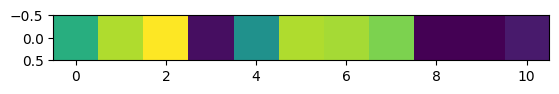

In [24]:
plt.imshow(layer.linear.bias.data.reshape(1, -1))

In [ ]:
from emlp.nn.pytorch import EMLPBlock
from emlp.nn.pytorch import Linear as EMLP_Linear
from emlp.reps import V, T, vis
from emlp.groups import Z, O
from emlp.datasets import O5Synthetic
from emlp.reps import T,Rep,Scalar
from emlp.nn import gated,gate_indices,uniform_rep

from emlp.nn.pytorch import EMLP, Linear as EMLP_Linear, BiLinear as EMLP_BiLinear, GatedNonlinearity
from symlie.model.networks.mlp import EMLP_wrapper


In [ ]:
set = O5Synthetic(N = 1)
group, repin, repout = O(5), set.rep_in, set.rep_out
repin, repout = repin(group), repout(group)

In [ ]:
vis(repin, repin)

In [ ]:
gated(repin)

In [ ]:
repin

In [ ]:
vis(gated(repin), gated(repin))

In [ ]:
model = EMLP_wrapper(
    implicit_layer_dims = [],
    vanilla_layer_dims = [10, 10, 1],
    bias = True,
    repin = repin,
    repout = repout,
    group = group,
)

In [ ]:
r1 = repin
r2 = uniform_rep(10, group)

linear = EMLP_Linear(r1, gated(r2))

# vis(r1, gated(r2))
vis(gated(r2), gated(r2))

# plt.imshow( linear.proj_b(linear.weight).detach() )




In [ ]:
r2

In [ ]:
gated(r2)

In [ ]:
p00 = (p0*1).to(torch.int)

p00 = p00.to(torch.int)


In [ ]:
p = torch.full((10, 10), -1)
p0 = torch.eye(5)
p[:5,:5] += (p0*1).to(torch.int)
p[5:,5:] += (p0*2).to(torch.int)
p[:5,5:] += (p0*3).to(torch.int)
p[5:,:5] += (p0*4).to(torch.int)

plt.imshow(p)
print(p)

In [ ]:
w = torch.randn(10, 10)

wp = torch.tensor([w.flatten()[p_i].item() if p_i != -1 else 0 for p_i in p.flatten()]).reshape(10,10)
plt.imshow(wp)
print(wp)

In [ ]:
for c in [10]:
    if isinstance(c, Rep):
        cc = c(group)
    else:
        cc =uniform_rep(c, group)
        print('uniform')
    print(cc)

reps = [repin, cc]
reps

In [ ]:
x_d = torch.tensor([11, 12, 13, 14, 15, 21, 22, 23, 24, 25]).view(1, 10)
x_d

In [ ]:
rng_a, rng_b, rng_d = torch.Generator(), torch.Generator(), torch.Generator()

In [ ]:
b = EMLPBlock(reps[0], reps[1])
b = EMLP_Linear(reps[0], reps[1])

b = lambda x: F.linear(x, wp)

In [ ]:
from symlie.data.transforms import TransformRefactored

transform = TransformRefactored()


rng_b.set_state(rng_a.get_state())
rng_d.set_state(rng_a.get_state())

x_a, x_b = x.clone(), x.clone()

out_d_prime = transform.transform(x_d, rng_d, shape = (1, 2, 5))
print(out_d_prime)


out_a = b(x_a)
out_a_prime = transform.transform(out_a, rng_a, shape = (1, 2, 5))

x_b_prime = transform.transform(x_b, rng_b, shape = (1, 2, 5))
out_b_prime = b(x_b_prime)

print(torch.allclose(out_a_prime, out_b_prime))
(out_a_prime - out_b_prime)[0]



In [ ]:
out_a_prime.shape, out_b_prime.shape

In [ ]:
transform.transform(x, torch.Generator(), shape = (1, 2, 5))

In [ ]:
tran

In [ ]:
x.shape

In [ ]:
b(x).shape

In [ ]:
args = parse_options(notebook=True)
args.config = 'emlp_mlp'
# args.do_return = True
args.logger = None
args.bias = True
args.lossweight_o = 0.
process_args(args)

# Training
model, trainer, datamodule = main(args)

In [ ]:
# from symlie.data.transforms import RandomScale, CustomRandomRotation, SpaceTranslate
# from typing import List, Union

# class RandomPermute():
#     def __init__(self, dim: int):
#         self.dim = dim
#         assert self.dim == 3, "Only dim = 3 is supported"

#     def __call__(self, x, rng):
#         return x[:, :, :, torch.randperm(x.shape[self.dim], generator=rng)]

# class TransformRefactored:
#     def __init__(self, eps_mult: List[float] = [1., 1., 1., 1.]):
#         self.eps_mult = torch.tensor(eps_mult)

#         self.scale = RandomScale()
#         self.rotate = CustomRandomRotation(only_flip = False)
#         self.space_translate_x = SpaceTranslate(dim = 2)
#         self.space_translate_y = SpaceTranslate(dim = 1)

#         self.random_permute = RandomPermute(dim = 3)

#     def transform(self, x, rng, shape):

#         epsilons = self.eps_mult

#         batch_size, features = x.shape
#         x = x.reshape(batch_size, *shape)

#         # x = self.scale(x, epsilons[0])

#         # x = self.rotate(x, epsilons[1])

#         # x, _ = self.space_translate_x(x, epsilons[2])
#         # x, _ = self.space_translate_y(x, epsilons[3])

#         x = self.random_permute(x, rng)

#         x = x.reshape(batch_size, features)

#         return x
    
# rng = torch.Generator() # Create a random number generator
# rng_b = torch.Generator() # Create a random number generator
# # rng_b = rng_b.manual_seed(rng.seed())

    


In [ ]:
# xa = torch.randn(2, 6)
# # xb = torch.randn(2, 6)
# xb = xa.clone()

# eps = torch.randn(4)

# shape = (1, 2, 3)

# transform = TransformRefactored(eps_mult = [0, 0, 1, 0])

# xa_prime = transform.transform(xa, rng, shape)

# # rng_b = rng_b.set_state(rng.get_state())
# xb_prime = transform.transform(xb, rng_b, shape)

# print(torch.allclose(xa_prime, xb_prime))
# xa, xa_prime, xb, xb_prime

In [ ]:
from emlp.datasets import O5Synthetic
from emlp.reps import V, vis
from emlp.groups import Z, O, SO

from torch.utils.data import DataLoader


In [ ]:
set = O5Synthetic(N = 20)

In [ ]:
plt.plot(set[0][0])

In [ ]:
N = 5
d=5
dim = 2*d
X = np.random.randn(N,dim)

ri = X.reshape(-1,2,5)
r1,r2 = ri.transpose(1,0,2)

def y_org(r1, r2):
    return np.sin(np.sqrt((r1**2).sum(-1)))-.5*np.sqrt((r2**2).sum(-1))**3 + (r1*r2).sum(-1)/(np.sqrt((r1**2).sum(-1))*np.sqrt((r2**2).sum(-1)))

def y_new(r1, r2):
    sin = np.sin(np.sqrt((r1**2).sum(-1)))
    abs = -.5*np.sqrt((r2**2).sum(-1))**3
    dot = (r1*r2).sum(-1)/(np.sqrt((r1**2).sum(-1))*np.sqrt((r2**2).sum(-1)))
    return sin + abs + dot


r1_new, r2_new = shuffle(r1), shuffle(r2)
np.allclose(y_org(r1, r2), y_new(r1_new, r2_new))


In [ ]:
r1

In [ ]:
def shuffle(X):
    return np.take(X,np.random.permutation(X.shape[0]),axis=1,out=X)

shuffle(r1)

In [ ]:
set.rep_out

In [ ]:
V

In [ ]:
group, repin, repout = O(3), set.rep_in, set.rep_out
print(group, repin, repout)
repin, repout = V + V, V ** 9
print(group, repin, repout)
repin, repout = repin(group), repout(group)
print(group, repin, repout)

vis(repin, repin)

In [ ]:
group = Z(5)

repin, repout = V(group), V(group)
vis(repin, repout)